## Grupo 4
# Pasos para crear el entorno de Conda
### Para instalar las librerias se debe usar en la terminal el comando: pip install -r requirements.txt
### Para instalar el entorno conda se debe usar en la terminal el comando: conda env create -f enviroment.yml

## Se realizó las siguientes actividades:
### 1.- Se ejecutó la Opción1 y se realizó un ejemplo propio 1
### 2.- Se ejecutó la Opción2 y se realizó un ejemplo propio 2
### 3.- De lo ejecutado del numeral 1 y del numeral 2 se realizó los archivos requirements.txt y enviroment.yml

# OPCIÓN 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creamos un dataset simulando un registro de conexiones de red
data = {
    'timestamp': pd.date_range(start='2023-01-01', periods=10, freq='h'),
    'ip_origen': ['192.168.1.' + str(i) for i in range(1, 11)],
    'ip_destino': ['10.0.0.' + str(i % 3 + 1) for i in range(10)],
    'puerto': [80, 443, 22, 3389, 8080, 80, 443, 22, 8080, 3389],
    'protocolo': ['HTTP', 'HTTPS', 'SSH', 'RDP', 'HTTP', 'HTTP', 'HTTPS', 'SSH', 'HTTP', 'RDP'],
    'bytes_enviados': np.random.randint(100, 10000, 10),
    'exito_conexion': [True, True, False, True, True, True, False, False, True, True]
}
# Creamos el DataFrame
df = pd.DataFrame(data)

print("1. Explorando el DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

1. Explorando el DataFrame:
            timestamp    ip_origen ip_destino  puerto protocolo  \
0 2023-01-01 00:00:00  192.168.1.1   10.0.0.1      80      HTTP   
1 2023-01-01 01:00:00  192.168.1.2   10.0.0.2     443     HTTPS   
2 2023-01-01 02:00:00  192.168.1.3   10.0.0.3      22       SSH   
3 2023-01-01 03:00:00  192.168.1.4   10.0.0.1    3389       RDP   
4 2023-01-01 04:00:00  192.168.1.5   10.0.0.2    8080      HTTP   

   bytes_enviados  exito_conexion  
0            1366            True  
1             293            True  
2            3269           False  
3             242            True  
4            4696            True  

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       10 non-null     datetime64[ns]
 1   ip_origen       10 non-null     object        
 2   ip_destino 

# Error 1
Aparece "/tmp/ipykernel_6372/4076785184.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'timestamp': pd.date_range(start='2023-01-01', periods=10, freq='H'),"
Se soluciono debido a que estaba la H en mayúscula y pide el cambio por h minúscula

In [3]:
# 2. Selección de datos
print("\n2. Selección de datos:")
# Seleccionar una columna (devuelve una Serie)
print("\nSelección de una columna (Serie):")
print(df['protocolo'])

# Seleccionar múltiples columnas (devuelve un DataFrame)
print("\nSelección de múltiples columnas (DataFrame):")
print(df[['ip_origen', 'protocolo', 'puerto']])

# Selección por índice con iloc
print("\nSelección por índice con iloc (primeras 2 filas, columnas 0 y 2):")
print(df.iloc[0:2, [0, 2]])

# Selección por nombre con loc
print("\nSelección por nombre con loc (filas donde protocolo es 'HTTP'):")
print(df.loc[df['protocolo'] == 'HTTP', ['timestamp', 'ip_origen', 'puerto']])


2. Selección de datos:

Selección de una columna (Serie):
0     HTTP
1    HTTPS
2      SSH
3      RDP
4     HTTP
5     HTTP
6    HTTPS
7      SSH
8     HTTP
9      RDP
Name: protocolo, dtype: object

Selección de múltiples columnas (DataFrame):
      ip_origen protocolo  puerto
0   192.168.1.1      HTTP      80
1   192.168.1.2     HTTPS     443
2   192.168.1.3       SSH      22
3   192.168.1.4       RDP    3389
4   192.168.1.5      HTTP    8080
5   192.168.1.6      HTTP      80
6   192.168.1.7     HTTPS     443
7   192.168.1.8       SSH      22
8   192.168.1.9      HTTP    8080
9  192.168.1.10       RDP    3389

Selección por índice con iloc (primeras 2 filas, columnas 0 y 2):
            timestamp ip_destino
0 2023-01-01 00:00:00   10.0.0.1
1 2023-01-01 01:00:00   10.0.0.2

Selección por nombre con loc (filas donde protocolo es 'HTTP'):
            timestamp    ip_origen  puerto
0 2023-01-01 00:00:00  192.168.1.1      80
4 2023-01-01 04:00:00  192.168.1.5    8080
5 2023-01-01 05:00:0

In [4]:
# 3. Filtrado de datos
print("\n3. Filtrado de datos:")
# Filtrar conexiones exitosas
conexiones_exitosas = df[df['exito_conexion'] == True]
print("\nConexiones exitosas:")
print(conexiones_exitosas[['timestamp', 'ip_origen', 'protocolo']])

# Filtrado múltiple (conexiones HTTP en puerto 80)
http_port80 = df[(df['protocolo'] == 'HTTP') & (df['puerto'] == 80)]
print("\nConexiones HTTP en puerto 80:")
print(http_port80)

# 4. Transformación de datos
print("\n4. Transformación de datos:")
# Añadir una nueva columna
df['hora'] = df['timestamp'].dt.hour
print("\nDataFrame con nueva columna 'hora':")
print(df[['timestamp', 'hora', 'protocolo']])

# Aplicar una función con apply
def clasificar_protocolo(protocolo):
    if protocolo in ['HTTP', 'HTTPS']:
        return 'WEB'
    elif protocolo == 'SSH':
        return 'ADMIN'
    else:
        return 'OTRO'

df['tipo_servicio'] = df['protocolo'].apply(clasificar_protocolo)
print("\nDataFrame con clasificación de servicios:")
print(df[['protocolo', 'tipo_servicio']])


3. Filtrado de datos:

Conexiones exitosas:
            timestamp     ip_origen protocolo
0 2023-01-01 00:00:00   192.168.1.1      HTTP
1 2023-01-01 01:00:00   192.168.1.2     HTTPS
3 2023-01-01 03:00:00   192.168.1.4       RDP
4 2023-01-01 04:00:00   192.168.1.5      HTTP
5 2023-01-01 05:00:00   192.168.1.6      HTTP
8 2023-01-01 08:00:00   192.168.1.9      HTTP
9 2023-01-01 09:00:00  192.168.1.10       RDP

Conexiones HTTP en puerto 80:
            timestamp    ip_origen ip_destino  puerto protocolo  \
0 2023-01-01 00:00:00  192.168.1.1   10.0.0.1      80      HTTP   
5 2023-01-01 05:00:00  192.168.1.6   10.0.0.3      80      HTTP   

   bytes_enviados  exito_conexion  
0            1366            True  
5            7971            True  

4. Transformación de datos:

DataFrame con nueva columna 'hora':
            timestamp  hora protocolo
0 2023-01-01 00:00:00     0      HTTP
1 2023-01-01 01:00:00     1     HTTPS
2 2023-01-01 02:00:00     2       SSH
3 2023-01-01 03:00:00     3 

In [5]:
# 5. Agregación de datos
print("\n5. Agregación de datos:")
# Agrupar por protocolo y contar conexiones
conteo_por_protocolo = df.groupby('protocolo').size()
print("\nConteo de conexiones por protocolo:")
print(conteo_por_protocolo)

# Estadísticas por protocolo
stats_por_protocolo = df.groupby('protocolo')['bytes_enviados'].agg(['count', 'mean', 'min', 'max'])
print("\nEstadísticas de bytes enviados por protocolo:")
print(stats_por_protocolo)


5. Agregación de datos:

Conteo de conexiones por protocolo:
protocolo
HTTP     4
HTTPS    2
RDP      2
SSH      2
dtype: int64

Estadísticas de bytes enviados por protocolo:
           count     mean   min   max
protocolo                            
HTTP           4  5506.25  1366  7992
HTTPS          2  4816.00   293  9339
RDP            2  3490.50   242  6739
SSH            2  4177.00  3269  5085


In [6]:
# 6. Pivotado de datos
print("\n6. Pivotado de datos:")
# Tabla pivote de bytes enviados por tipo de servicio y protocolo
pivot = pd.pivot_table(df, 
                      values='bytes_enviados', 
                      index='tipo_servicio', 
                      columns='exito_conexion', 
                      aggfunc='mean')
print("\nTabla pivote de bytes enviados por tipo de servicio y éxito de conexión:")
print(pivot)


6. Pivotado de datos:

Tabla pivote de bytes enviados por tipo de servicio y éxito de conexión:
exito_conexion   False   True 
tipo_servicio                 
ADMIN           4177.0     NaN
OTRO               NaN  3490.5
WEB             9339.0  4463.6


In [7]:
# 7. Detección de anomalías simples
print("\n7. Detección de anomalías simples:")
# Calcular el Z-score para identificar valores atípicos en bytes_enviados
df['z_score'] = (df['bytes_enviados'] - df['bytes_enviados'].mean()) / df['bytes_enviados'].std()
anomalias = df[abs(df['z_score']) > 1.5]  # Consideramos como anómalos Z-scores > 1.5
print("\nPosibles conexiones anómalas por volumen de datos transferidos:")
print(anomalias[['timestamp', 'ip_origen', 'protocolo', 'bytes_enviados', 'z_score']])


7. Detección de anomalías simples:

Posibles conexiones anómalas por volumen de datos transferidos:
Empty DataFrame
Columns: [timestamp, ip_origen, protocolo, bytes_enviados, z_score]
Index: []


# OPCIÓN 2

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Usaremos los datos generados en el ejemplo anterior
# Para simplificar, recreamos un conjunto similar pero más pequeño
# Generar 500 registros de logs simulados
np.random.seed(42)
# Lista de eventos de seguridad
eventos = ['login_success', 'login_failure', 'file_access', 'admin_login', 
           'password_change', 'firewall_block', 'suspicious_activity', 
           'malware_detected', 'port_scan']
# Generar timestamps para una semana
fechas = pd.date_range(start='2023-01-01', periods=7)
timestamps = []
for fecha in fechas:
    for hora in range(24):
        for _ in range(3):  # 3 eventos por hora aprox
            timestamps.append(fecha + pd.Timedelta(hours=hora) + 
                             pd.Timedelta(minutes=np.random.randint(60)))
# Ajustar al número de registros deseados
timestamps = timestamps[:500]
# Generar IPs aleatorias
def random_ip():
    return f"{np.random.randint(1, 256)}.{np.random.randint(1, 256)}.{np.random.randint(1, 256)}.{np.random.randint(1, 256)}"
# Usuarios del sistema
usuarios = ['admin', 'user1', 'user2', 'user3', 'system', 'guest', None]
# Generar datos simulados
data = {
    'timestamp': timestamps,
    'ip_origen': [random_ip() for _ in range(500)],
    'evento': np.random.choice(eventos, 500, p=[0.3, 0.2, 0.2, 0.05, 0.05, 0.08, 0.07, 0.03, 0.02]),
    'usuario': np.random.choice(usuarios, 500, p=[0.1, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1]),
    'severidad': np.random.choice(['low', 'medium', 'high', 'critical'], 500, p=[0.5, 0.3, 0.15, 0.05]),
    'exitoso': np.random.choice([True, False], 500, p=[0.8, 0.2]),
}
# Crear DataFrame
logs_df = pd.DataFrame(data)
# Configurar timestamp como índice
logs_df['timestamp'] = pd.to_datetime(logs_df['timestamp'])
logs_df = logs_df.sort_values('timestamp')
# Ahora creamos las visualizaciones
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

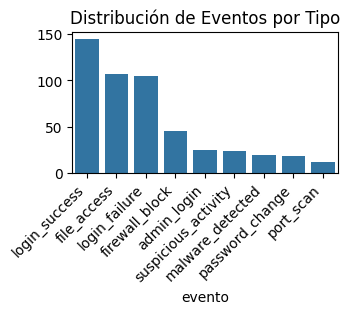

In [9]:
# 1. Distribución de eventos por tipo
plt.subplot(2, 2, 1)
eventos_count = logs_df['evento'].value_counts()
sns.barplot(x=eventos_count.index, y=eventos_count.values)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Eventos por Tipo')
plt.tight_layout()

Text(0.5, 1.0, 'Distribución de Eventos por Severidad')

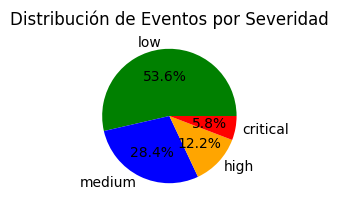

In [10]:
# 2. Distribución de eventos por severidad
plt.subplot(2, 2, 2)
severidad_count = logs_df['severidad'].value_counts()
colors = {'low': 'green', 'medium': 'blue', 'high': 'orange', 'critical': 'red'}
plt.pie(severidad_count, labels=severidad_count.index, autopct='%1.1f%%',
        colors=[colors[sev] for sev in severidad_count.index])
plt.title('Distribución de Eventos por Severidad')

Text(0, 0.5, 'Número de Eventos')

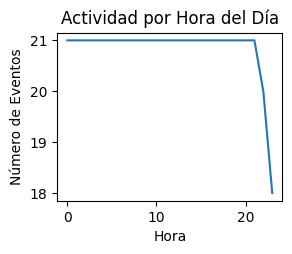

In [11]:
# 3. Actividad por hora del día
plt.subplot(2, 2, 3)
logs_df['hour'] = logs_df['timestamp'].dt.hour
hourly_count = logs_df.groupby('hour').size()
sns.lineplot(x=hourly_count.index, y=hourly_count.values)
plt.title('Actividad por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Número de Eventos')

<Figure size 1200x600 with 0 Axes>

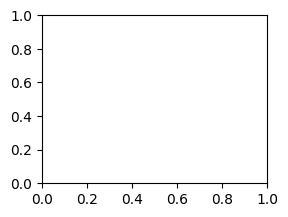

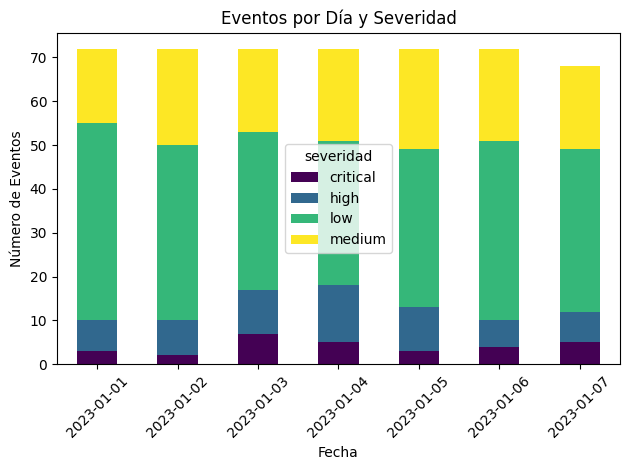

<Figure size 1200x600 with 0 Axes>

In [12]:
# 4. Eventos por día y por severidad
plt.subplot(2, 2, 4)
logs_df['date'] = logs_df['timestamp'].dt.date
pivot_table = pd.crosstab(logs_df['date'], logs_df['severidad'])
pivot_table.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Eventos por Día y Severidad')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('security_dashboard.png')
# Crear gráfico de actividad sospechosa
plt.figure(figsize=(12, 6))

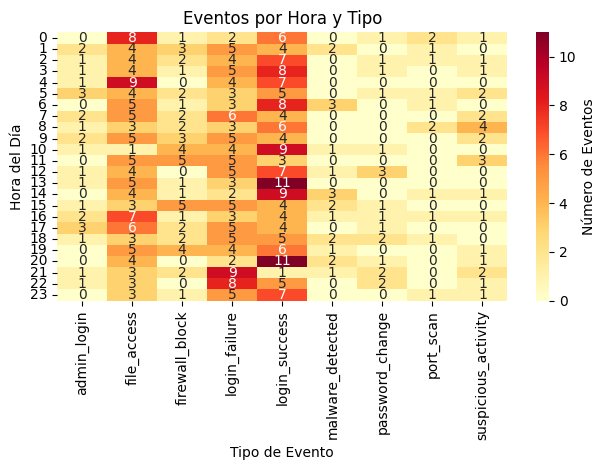

In [13]:
# 5. Mapa de calor de actividad por hora y tipo de evento
logs_df['hour'] = logs_df['timestamp'].dt.hour
heatmap_data = pd.crosstab(logs_df['hour'], logs_df['evento'])
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': 'Número de Eventos'})
plt.title('Eventos por Hora y Tipo')
plt.xlabel('Tipo de Evento')
plt.ylabel('Hora del Día')
plt.tight_layout()
plt.savefig('activity_heatmap.png')

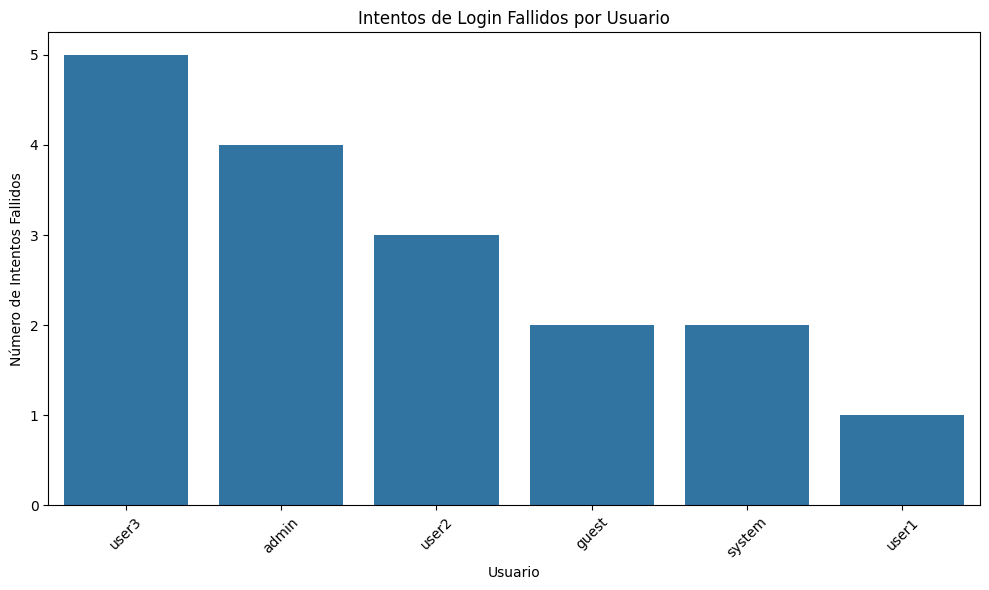

In [14]:
# 6. Análisis de accesos fallidos por usuario
plt.figure(figsize=(10, 6))
failed_logins = logs_df[(logs_df['evento'] == 'login_failure') & (logs_df['exitoso'] == False)]
user_failures = failed_logins['usuario'].value_counts()
sns.barplot(x=user_failures.index.fillna('anónimo'), y=user_failures.values)
plt.title('Intentos de Login Fallidos por Usuario')
plt.xlabel('Usuario')
plt.ylabel('Número de Intentos Fallidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('failed_logins_by_user.png')

Visualizaciones generadas correctamente. Revisa los archivos .png generados.


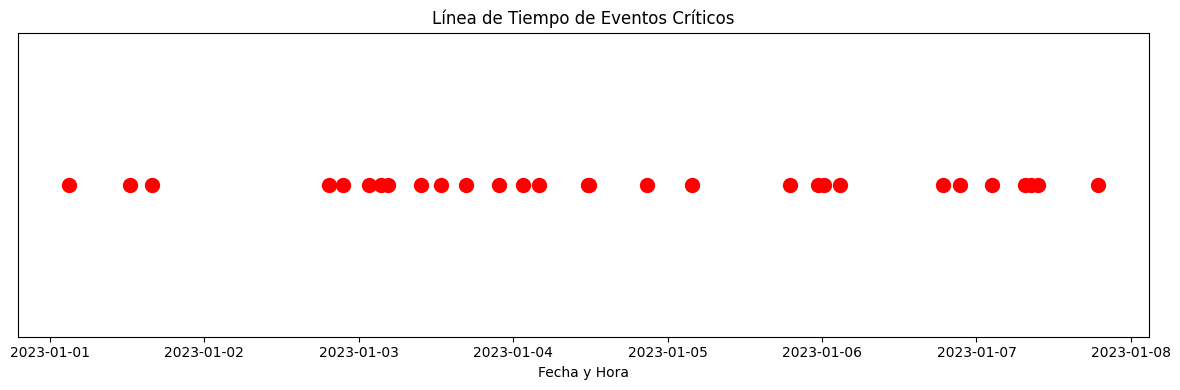

In [15]:
# 7. Línea de tiempo de eventos críticos
plt.figure(figsize=(12, 4))
critical_events = logs_df[logs_df['severidad'] == 'critical']
plt.scatter(critical_events['timestamp'], [1]*len(critical_events), c='red', s=100)
plt.yticks([])
plt.title('Línea de Tiempo de Eventos Críticos')
plt.xlabel('Fecha y Hora')
plt.tight_layout()
plt.savefig('critical_events_timeline.png')
print("Visualizaciones generadas correctamente. Revisa los archivos .png generados.")